# Step 2 — Exploratory Data Analysis
### gametheory-sweetcrete

This notebook explores the cleaned Sweetcrete lab dataset to understand what drives
compressive strength before modeling. It loads data through `src/data_cleaning.py`
(our single source of truth) so results stay reproducible, and saves every figure to
`results/figures/` so the paper and poster can pull from one place.

**Selected features (from Step 1, SHAP-ranked):** `Age_days`, `Cement_lbs`,
`PCC_Fraction`, `WaterCement_Ratio`, `CoarseAgg_lbs` &nbsp;|&nbsp; **Target:** `Strength_MPa`

In [10]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- locate repo root robustly (works whether Jupyter starts in repo root or notebooks/) ---
p = Path.cwd()
while not (p / "src").exists() and p != p.parent:
    p = p.parent
ROOT = p
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))

from data_cleaning import clean_sweetcrete, SELECTED_FEATURES, TARGET

df = clean_sweetcrete(str(ROOT / "data" / "raw" / "Sweetcrete_Master_Final.csv"))
print("Clean dataset:", df.shape)
print("Strength range: %.1f - %.1f MPa" % (df[TARGET].min(), df[TARGET].max()))
df[SELECTED_FEATURES + [TARGET]].describe().round(2)

Clean dataset: (178, 24)
Strength range: 2.2 - 52.6 MPa


,Age_days,Cement_lbs,PCC_Fraction,WaterCement_Ratio,CoarseAgg_lbs,Strength_MPa
count,178.00,178.00,178.00,178.00,178.00,178.00
mean,36.26,75.09,0.05,0.59,227.24,27.07
std,32.96,21.46,0.03,0.14,23.62,12.80
min,1.00,46.98,0.00,0.44,214.49,2.15
25%,7.00,61.07,0.01,0.47,221.41,15.82
50%,28.00,75.16,0.04,0.55,221.41,28.44
75%,56.00,85.33,0.07,0.67,221.41,37.44
max,90.00,129.18,0.10,0.87,304.44,52.63


## 1. Target distribution
What does the compressive-strength variable we are predicting actually look like?

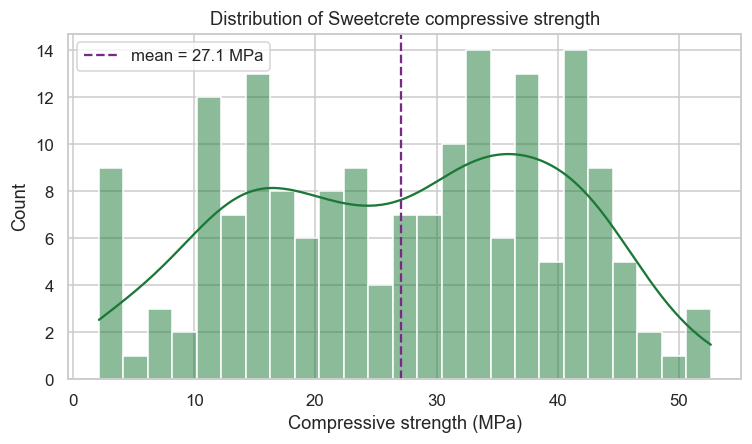

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.histplot(df[TARGET], bins=25, kde=True, color="#1b7837", ax=ax)
ax.axvline(df[TARGET].mean(), color="#762a83", ls="--", lw=1.5,
           label=f"mean = {df[TARGET].mean():.1f} MPa")
ax.set_xlabel("Compressive strength (MPa)"); ax.set_ylabel("Count")
ax.set_title("Distribution of Sweetcrete compressive strength")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "eda_target_distribution.png", bbox_inches="tight")
plt.show()

## 2. Strength development over curing age
Age was the single strongest driver in the SHAP ranking. Here we trace mean strength
gain over time, split by PCC replacement level.

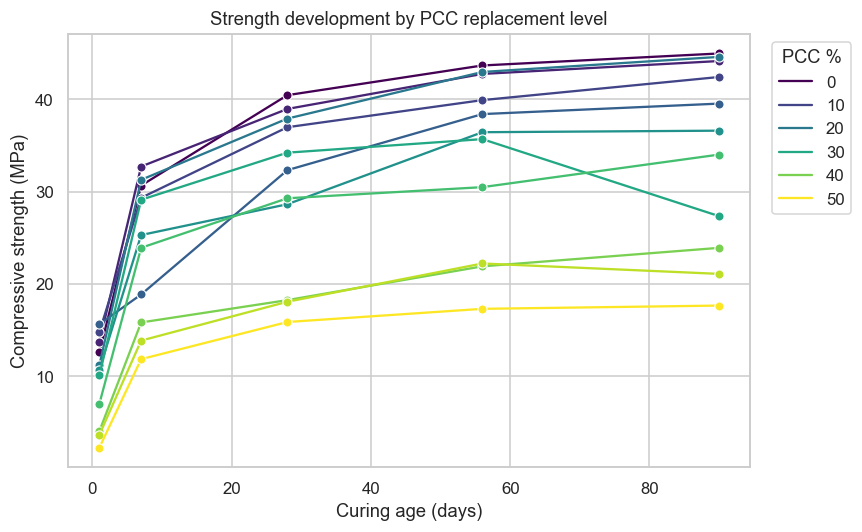

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df, x="Age_days", y=TARGET, hue="PCC_%",
             palette="viridis", marker="o", errorbar=None, ax=ax)
ax.set_xlabel("Curing age (days)"); ax.set_ylabel("Compressive strength (MPa)")
ax.set_title("Strength development by PCC replacement level")
ax.legend(title="PCC %", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "eda_strength_vs_age.png", bbox_inches="tight")
plt.show()

## 3. Effect of PCC replacement on 28-day strength
28 days is the standard concrete benchmark age. How does swapping cement for the
sugar-beet byproduct (PCC) affect strength at that point?

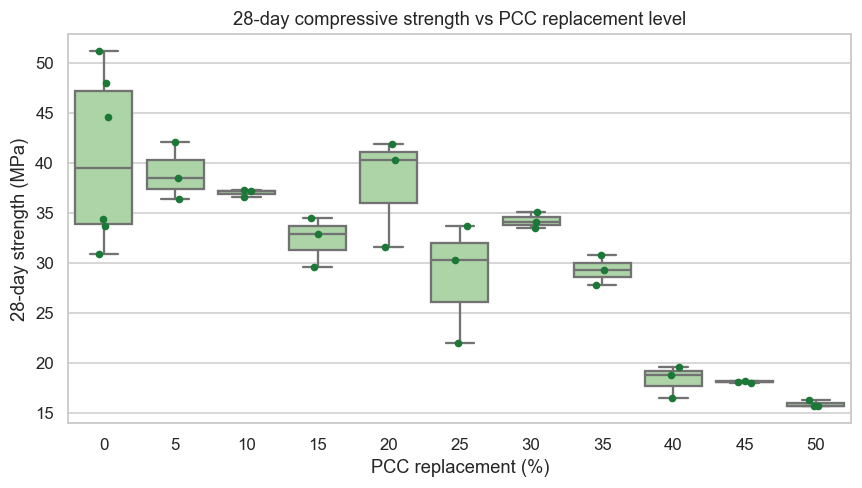

In [13]:
d28 = df[df["Age_days"] == 28]
fig, ax = plt.subplots(figsize=(8, 4.6))
sns.boxplot(data=d28, x="PCC_%", y=TARGET, color="#a6dba0", ax=ax)
sns.stripplot(data=d28, x="PCC_%", y=TARGET, color="#1b7837", size=5, ax=ax)
ax.set_xlabel("PCC replacement (%)"); ax.set_ylabel("28-day strength (MPa)")
ax.set_title("28-day compressive strength vs PCC replacement level")
plt.tight_layout(); plt.savefig(FIG / "eda_strength_vs_pcc_28d.png", bbox_inches="tight")
plt.show()

## 4. Correlation among selected features and target
A quick check on how the five modeling features relate to strength and to each other.

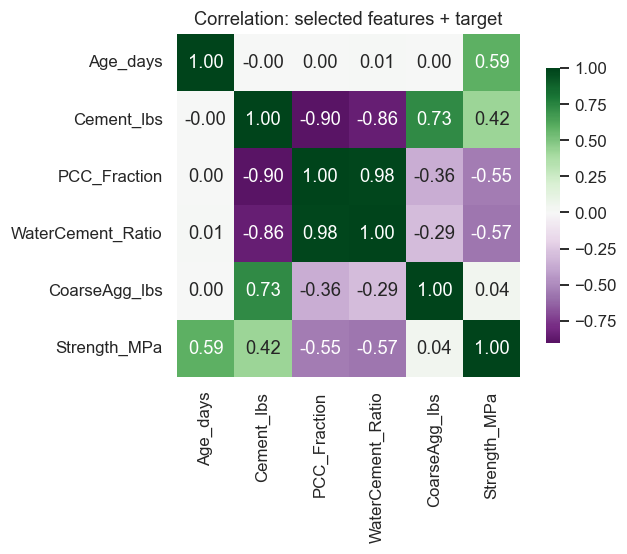

In [14]:
corr = df[SELECTED_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PRGn", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation: selected features + target")
plt.tight_layout(); plt.savefig(FIG / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Key takeaways

1. **Strength is well-behaved after cleaning** — roughly 2–53 MPa, no physically impossible values.
2. **Age dominates.** Strength climbs steeply from 1 to 28 days, then flattens — the classic concrete curing curve, and consistent with `Age_days` topping the SHAP ranking.
3. **PCC has a cost.** Higher cement-replacement levels generally trend toward lower strength, but moderate PCC levels still reach usable strength — which is exactly the trade-off the optimization step (Step 6) will navigate.
4. **Feature correlations confirm the Step 1 finding:** the PCC/water-cement family moves together (the fixed-recipe-per-PCC-level experimental design), so the independent predictive lift comes mainly from Age + Cement + PCC.

**Next:** Step 3 — preprocessing pipeline and a small-data-aware train/test strategy.